---
title: 'Expected Performance of a Mean-Reversion Trading Strategy - Part 2'
date: 2026-03-01
description: "What happens to the performance of a mean-reversion strategy when the fair value is estimated with a constant bias?"
categories: [Quantitative Finance, Trading Strategies, Stochastic Processes]
content-type: "series"
series-id: "mean-reversion-strategy"
series-title: "Expected Performance of a Mean-Reversion Trading Strategy"
series-part: 2
project-ids: [mean-reversion-strategy]
---

In [Part 1](../mean-reversion-strategy-1/) we derived the expected performance of a continuously rebalanced mean-reversion strategy under the assumption that the trader knows the asset's true fair value exactly and can rebalance continuously frictionlessly. The asymptotic Sharpe ratio turned out to depend only on the speed of mean reversion $\theta$:

$$
\mathrm{SR}_\infty = \sqrt{\frac{\theta}{2}}.
$$

In practice, fair value is never observed directly and must be estimated. As a first order approximation, how does a persistent error in the fair-value estimate affect the strategy's risk-adjusted performance?

This post answers that question first in the simplest possible setting: that the fair-value error is a known constant $M$. Even in this stylised case, the results are instructive:

- The **expected PnL is unchanged** — the bias term integrates to $M X_t$, which has zero expectation under the OU dynamics.
- The **risk increases** — the trader holds a systematic offset position that adds to the cumulative local variance of the PnL path.


In [ ]:
#| echo: false
#| output: false
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

rng = np.random.default_rng(42)

# --- OU helpers (same conventions as Part 1) ---

def s2(t, theta, sigma):
    """Variance of X_t: sigma^2/(2*theta) * (1 - exp(-2*theta*t))."""
    return sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))


def simulate_ou(theta, sigma, T, dt, n_paths, rng=rng):
    """Euler–Maruyama simulation of dX = -theta*X dt + sigma dW, X_0=0."""
    n_steps = int(T / dt)
    X = np.zeros((n_paths, n_steps + 1))
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = rng.standard_normal(n_paths) * sqrt_dt
        X[:, i + 1] = X[:, i] - theta * X[:, i] * dt + sigma * dW
    return X


def pnl_paths(X, M, sigma, dt):
    """Compute PnL paths: dY = -(X - M) dX, discretised."""
    dX = np.diff(X, axis=1)
    X_mid = X[:, :-1]
    dY = -(X_mid - M) * dX
    Y = np.cumsum(dY, axis=1)
    return np.concatenate([np.zeros((X.shape[0], 1)), Y], axis=1)


print("Helpers loaded.")

Helpers loaded.


# Model

We continue with our setup from Part 1. The log price is $p_t = \log P_t$, the true log fair value is $v_t$ (assumed constant), and the true mispricing follows an Ornstein–Uhlenbeck process:

$$
dX_t = -\theta X_t\, dt + \sigma\, dW_t, \qquad X_0 = 0,
$$

so that $X_t = p_t - v_t \sim \mathcal{N}(0, s_t^2)$ with $s_t^2 = \frac{\sigma^2}{2\theta}(1 - e^{-2\theta t})$.

Suppose the trader does not observe $v_t$ directly but instead uses an estimate $\tilde{v}_t$ that carries a constant bias $M$ in log terms:

$$
\tilde{v}_t = v_t + M.
$$

The trader's perceived mispricing is therefore

$$
\tilde{X}_t = p_t - \tilde{v}_t = (p_t - v_t) - M = X_t - M.
$$

When $M > 0$ the trader systematically under-estimates the asset's price level (thinks it is cheaper than it really is); when $M < 0$ the trader over-estimates it.

The strategy trades against the estimated mispricing $\tilde{X}_t$. Since the fair value is constant, $dp_t = dX_t$, and the instantaneous PnL is

$$
dY_t = -\tilde{X}_t\, dp_t = -(X_t - M)\, dX_t.
$$

# Closed-Form Terminal PnL

Splitting the PnL into the unbiased part (already computed in Part 1) and the bias-induced part:

$$
dY_t = \underbrace{-X_t\, dX_t}_{\text{Part 1}} + \underbrace{M\, dX_t}_{\text{bias term}}.
$$

Integrating from $0$ to $t$ with $X_0 = 0$:

- From Part 1: $\displaystyle\int_0^t -X_u\, dX_u = \frac{\sigma^2 t - X_t^2}{2}$.
- The bias term: $\displaystyle\int_0^t M\, dX_u = M(X_t - X_0) = M X_t$.

Combining:

$$
\boxed{Y_t = \frac{\sigma^2 t - X_t^2}{2} + M X_t.}
$$

This is a quadratic-plus-linear function of the Gaussian random variable $X_t \sim \mathcal{N}(0, s_t^2)$, which fully determines the distribution of $Y_t$.

## Expected PnL Is Unchanged

Taking the expectation of $Y_t$:

$$
\mathbb{E}[Y_t]
= \frac{\sigma^2 t}{2} - \frac{1}{2}\,\mathbb{E}[X_t^2] + M\,\mathbb{E}[X_t]
= \frac{\sigma^2 t}{2} - \frac{s_t^2}{2} + 0.
$$

The bias term drops out by a direct calculation: since $M$ is constant, the bias-induced PnL derived above is $\int_0^t M\, dX_u = M X_t$, and therefore $\mathbb{E}[M X_t] = M \cdot \mathbb{E}[X_t] = 0$ under the zero-mean OU dynamics with $X_0 = 0$. Intuitively, the constant offset in the signal adds as much expected gain on favourable mispricings as it loses on unfavourable ones.

The expected annualized PnL is therefore identical to the unbiased case from Part 1:

$$
\boxed{\mathbb{E}\!\left[\frac{Y_t}{t}\right] = \frac{1}{2}\left(\sigma^2 - \frac{s_t^2}{t}\right).}
$$


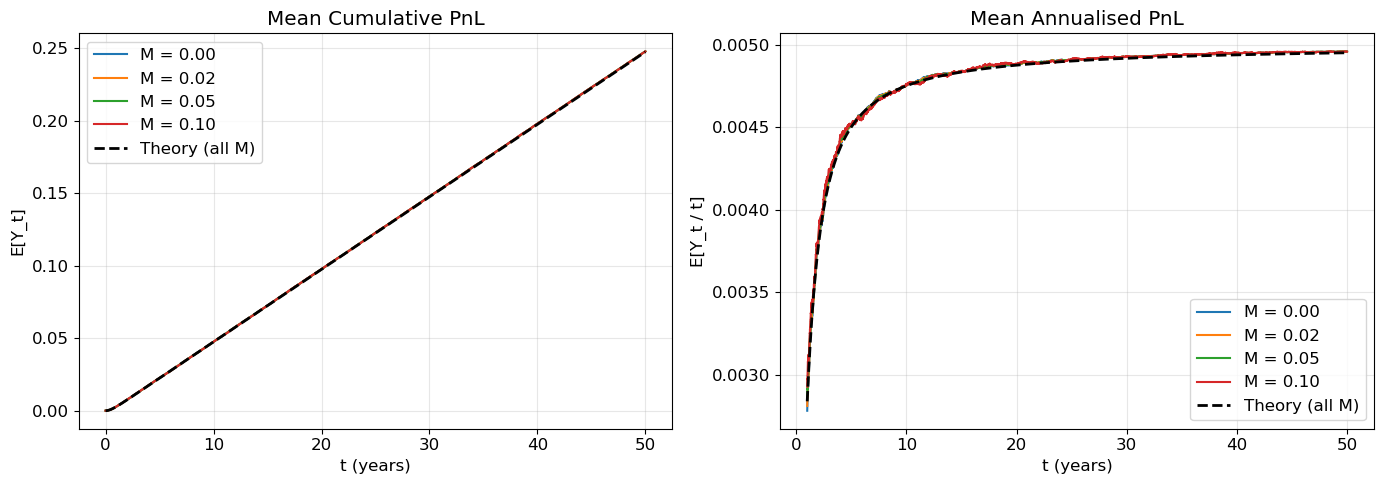

Observation: All bias levels produce the same expected PnL — the bias washes out.


In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-pnl-bias
#| fig-cap: "Mean cumulative (left) and annualised (right) PnL for different constant biases $M$. The bias does not affect expected PnL — all curves collapse onto the theory prediction."
# --- Simulation: expected annualised PnL for different biases M ---
theta, sigma, T, dt = 1.0, 0.10, 50, 1 / 252
n_paths = 5_000
M_values = [0.0, 0.02, 0.05, 0.10]

X = simulate_ou(theta, sigma, T, dt, n_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: mean cumulative PnL
t_grid = np.arange(X.shape[1]) * dt
theory_mean = 0.5 * (sigma**2 * t_grid - s2(t_grid, theta, sigma))

for M in M_values:
    Y = pnl_paths(X, M, sigma, dt)
    axes[0].plot(t_grid, Y.mean(axis=0), label=f"M = {M:.2f}")

axes[0].plot(t_grid, theory_mean, "k--", lw=2, label="Theory (all M)")
axes[0].set(xlabel="t (years)", ylabel="E[Y_t]", title="Mean Cumulative PnL")
axes[0].legend()

# Right panel: mean annualised PnL (after burn-in)
burn = int(1 / dt)  # skip first year for stability
t_ann = t_grid[burn:]
theory_ann = 0.5 * (sigma**2 - s2(t_ann, theta, sigma) / t_ann)

for M in M_values:
    Y = pnl_paths(X, M, sigma, dt)
    ann = Y[:, burn:] / t_ann
    axes[1].plot(t_ann, ann.mean(axis=0), label=f"M = {M:.2f}")

axes[1].plot(t_ann, theory_ann, "k--", lw=2, label="Theory (all M)")
axes[1].set(xlabel="t (years)", ylabel="E[Y_t / t]", title="Mean Annualised PnL")
axes[1].legend()

print("Observation: All bias levels produce the same expected PnL — the bias washes out.")

plt.tight_layout()plt.show()

## Terminal Variance Increases with Bias

As confirmed in @fig-pnl-bias, the mean is unaffected, but the dispersion of $Y_t$ grows with $|M|$. Writing $Y_t = \frac{\sigma^2 t}{2} + M X_t - \frac{X_t^2}{2}$, the constant drops out of the variance. Using standard Gaussian identities for $X \sim \mathcal{N}(0, s^2)$:

- $\operatorname{Var}(X) = s^2$,
- $\operatorname{Var}(X^2) = 2 s^4$ (since $\mathbb{E}[X^4] = 3s^4$),
- $\operatorname{Cov}(X, X^2) = \mathbb{E}[X^3] = 0$ (odd moment of a symmetric distribution),

we get

$$
\operatorname{Var}(Y_t) = M^2\, \operatorname{Var}(X_t) + \tfrac{1}{4}\operatorname{Var}(X_t^2)
$$

$$
\boxed{\operatorname{Var}(Y_t) = M^2 s_t^2 + \frac{1}{2}\, s_t^4.}
$$

The first term, $M^2 s_t^2$, is entirely due to the bias. Even though the bias does not shift the average outcome, it creates a persistent directional long or short tilt roughly $M$ that translates OU fluctuations into PnL variance.

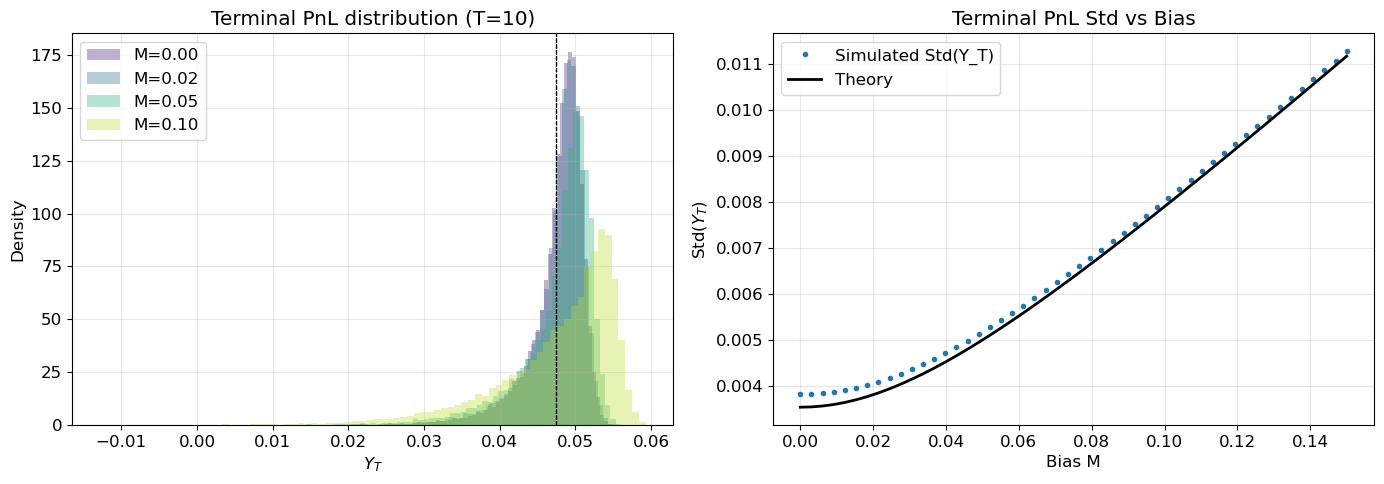

Theory std at M=0: 0.0035,  at M=0.10: 0.0079


In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-terminal-pnl
#| fig-cap: 'Terminal PnL distributions widen with bias (left). The standard deviation of $Y_T$ matches the closed-form $\sqrt{M^2 s_T^2 + s_T^4/2}$ (right).'
# --- Simulation: terminal PnL distribution for different M ---
theta, sigma, T, dt = 1.0, 0.10, 10, 1 / 252
n_paths = 20_000
X = simulate_ou(theta, sigma, T, dt, n_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_values)))
st2 = s2(T, theta, sigma)

for M, c in zip(M_values, colors):
    Y = pnl_paths(X, M, sigma, dt)
    Y_T = Y[:, -1]

    # Simulated
    axes[0].hist(Y_T, bins=80, density=True, alpha=0.35, color=c, label=f"M={M:.2f}")

    # Theory: mean & std
    mu_th = 0.5 * (sigma**2 * T - st2)
    var_th = M**2 * st2 + 0.5 * st2**2
    axes[0].axvline(mu_th, color="k", ls="--", lw=0.8)

axes[0].set(xlabel="$Y_T$", ylabel="Density", title=f"Terminal PnL distribution (T={T})")
axes[0].legend()

# Right panel: simulated vs theoretical std
M_scan = np.linspace(0, 0.15, 50)
sim_std = []
for M in M_scan:
    Y = pnl_paths(X, M, sigma, dt)
    sim_std.append(Y[:, -1].std())
theory_std = np.sqrt(M_scan**2 * st2 + 0.5 * st2**2)

axes[1].plot(M_scan, sim_std, "o", ms=3, label="Simulated Std(Y_T)")
axes[1].plot(M_scan, theory_std, "k-", lw=2, label="Theory")
axes[1].set(xlabel="Bias M", ylabel="Std($Y_T$)", title="Terminal PnL Std vs Bias")
axes[1].legend()

print(f"Theory std at M=0: {np.sqrt(0.5 * st2**2):.4f},  at M=0.10: {np.sqrt(0.10**2 * st2 + 0.5 * st2**2):.4f}")

plt.tight_layout()plt.show()

# Quadratic Variation

The terminal variance $\operatorname{Var}(Y_t/t)$ shrinks as $O(1/t^2)$ at long horizons. That makes it a poor measure of the volatility actually experienced along the PnL path: a strategy can have vanishing endpoint dispersion while still accumulating substantial fluctuations in between. A more informative object is the quadratic variation of the PnL process, $\langle Y\rangle_t$, which records the cumulative local variance of the martingale component of $Y$. Part 1 motivated quadratic variation through drawdown and margin intuition; the precise statement is that $\frac{1}{t}\mathbb{E}[\langle Y\rangle_t]$ converges to a finite, non-degenerate long-run variance rate as $t\to\infty$, whereas $\operatorname{Var}(Y_t/t) \to 0$.

From the OU dynamics $dX_t = -\theta X_t\, dt + \sigma\, dW_t$, the PnL differential is

$$
dY_t = -(X_t - M)\, dX_t = \theta X_t(X_t - M)\, dt - \sigma(X_t - M)\, dW_t.
$$

The quadratic variation of $Y$ accumulates only through the martingale part:

$$
d\langle Y \rangle_t = \sigma^2 (X_t - M)^2\, dt.
$$

Taking expectations:

$$
\mathbb{E}[(X_t - M)^2] = \mathbb{E}[X_t^2] - 2M\,\mathbb{E}[X_t] + M^2 = s_t^2 + M^2.
$$

The expected annualised quadratic variation is therefore

$$
\frac{1}{t}\,\mathbb{E}[\langle Y \rangle_t]
= \frac{1}{t}\int_0^t \sigma^2(s_u^2 + M^2)\, du
= \sigma^2 M^2 + \frac{1}{t}\int_0^t \sigma^2 s_u^2\, du.
$$

Reusing the integral identity from Part 1,

$$
\boxed{
\frac{1}{t}\,\mathbb{E}[\langle Y \rangle_t]
= \sigma^2 M^2 + \frac{\sigma^2}{2\theta}\left(\sigma^2 - \frac{s_t^2}{t}\right).
}
$$

Compared to the unbiased case, we pick up an additive term $\sigma^2 M^2$ — a constant "floor" of local variance from the systematic offset position. As $t\to\infty$, the annualised expected QV converges to $\sigma^2 M^2 + \sigma^4/(2\theta)$, a finite positive limit, while $\operatorname{Var}(Y_t/t) \to 0$. This contrast is precisely why the annualised expected QV, rather than the terminal variance, serves as the denominator in the risk-adjusted return defined below. @fig-terminal-pnl confirms both results: terminal PnL distributions widen with bias, and the simulated standard deviation matches the theory.


# Expected Sharpe Ratio

Following Part 1, we define a path-based risk-adjusted return by placing the square root of the annualised expected quadratic variation in the denominator:

$$
\mathrm{SR}_t := \frac{\mathbb{E}[Y_t / t]}{\sqrt{\mathbb{E}[\langle Y \rangle_t] / t}}.
$$

This differs from the classical Sharpe ratio, which uses $\sqrt{\operatorname{Var}(Y_t/t)}$ in the denominator. As shown above, the classical denominator decays as $O(1/t)$ and diverges to $+\infty$ at long horizons, while the path-based denominator converges to a finite limit — making $\mathrm{SR}_t$ the well-defined long-run object.

Substituting our expressions for the numerator and denominator and writing $\alpha_t = \sigma^2 - s_t^2/t$ for brevity:

$$
\boxed{
\mathrm{SR}_t
= \frac{\alpha_t / 2}{\sqrt{\sigma^2 M^2 + \frac{\sigma^2}{2\theta}\, \alpha_t}}.
}
$$

## Asymptotic Sharpe Ratio

As $t \to \infty$, $s_t^2 \to \sigma^2/(2\theta)$ and $s_t^2/t \to 0$, so $\alpha_t \to \sigma^2$. Hence

$$
\mathrm{SR}_\infty
= \frac{\sigma^2/2}{\sqrt{\sigma^2 M^2 + \sigma^4/(2\theta)}}
= \frac{\sigma/2}{\sqrt{M^2 + \sigma^2/(2\theta)}}.
$$

To interpret this, define the stationary mispricing scale $s_\infty = \sigma/\sqrt{2\theta}$ (the long-run standard deviation of $X_t$) and the dimensionless bias $\xi = M / s_\infty$. Then $2\theta M^2/\sigma^2 = \xi^2$ and the asymptotic Sharpe ratio factorises as

$$
\boxed{
\mathrm{SR}_\infty
= \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \xi^2}}.
}
$$

The first factor $\sqrt{\theta/2}$ is the unbiased Sharpe from Part 1. The second factor is a penalty that depends entirely on $\xi$ — how large the bias is relative to the natural fluctuation amplitude of the mispricing:

- When $M = 0$ ($\xi = 0$), the penalty is $1$ and we recover Part 1.
- For a fixed absolute bias $M$, the penalty worsens with $\theta$, since faster mean reversion shrinks $s_\infty$ and inflates $\xi = M/s_\infty$. The unbiased strategy would have captured proportionally larger gains, making the same constant offset relatively more costly.
- For a fixed standardised bias $\xi$, the penalty factor $(1 + \xi^2)^{-1/2}$ is independent of $\theta$ — it depends only on how large the bias is relative to the stationary fluctuation amplitude.
- The penalty is symmetric in $M$: over-estimating and under-estimating fair value by the same amount are equally harmful.


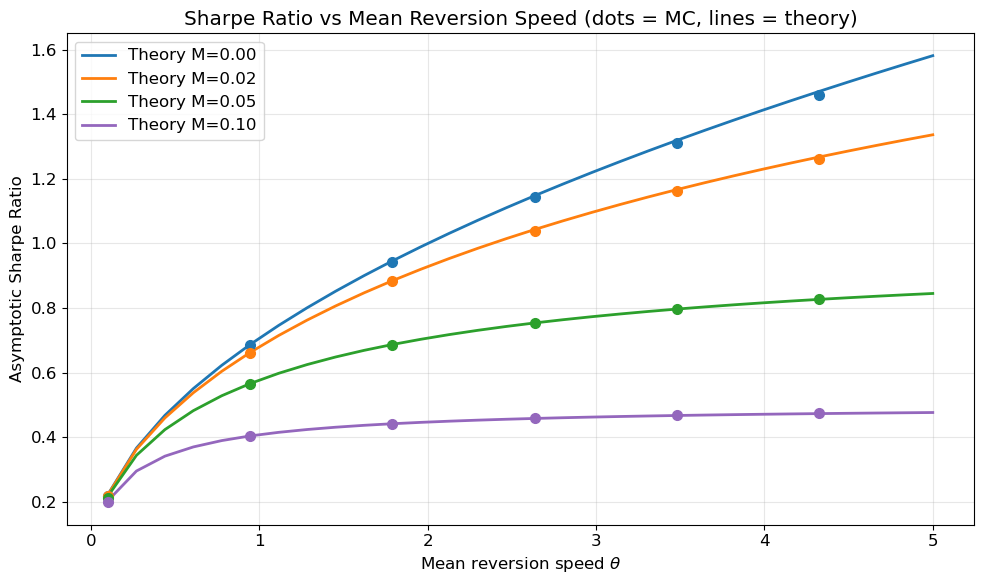

In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-theta-bias
#| fig-cap: 'Asymptotic Sharpe ratio vs mean-reversion speed $\theta$ for different biases. Lines are the closed-form formula; dots are Monte Carlo estimates.'
# --- Simulation: Asymptotic Sharpe Ratio vs theta for different M ---

def sr_asymptotic(theta, sigma, M):
    """Closed-form asymptotic SR with bias M."""
    return np.sqrt(theta / 2) / np.sqrt(1 + 2 * theta * M**2 / sigma**2)


theta_range = np.linspace(0.1, 5.0, 30)
sigma = 0.10
T, dt, n_paths = 100, 1 / 252, 1_000
M_values_sr = [0.0, 0.02, 0.05, 0.10]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 0.4, len(M_values_sr)))

for M, c in zip(M_values_sr, colors):
    # Analytical curve
    sr_th = sr_asymptotic(theta_range, sigma, M)
    ax.plot(theta_range, sr_th, "-", color=c, lw=2, label=f"Theory M={M:.2f}")

    # Monte Carlo points (subset of theta values)
    theta_sim = theta_range[::5]
    sr_sim = []
    for th in theta_sim:
        X = simulate_ou(th, sigma, T, dt, n_paths, rng=np.random.default_rng(123))
        Y = pnl_paths(X, M, sigma, dt)
        t_grid = np.arange(X.shape[1]) * dt

        # Annualised mean PnL
        mean_pnl = (Y[:, -1] / T).mean()

        # Annualised QV via discrete approximation
        dX = np.diff(X, axis=1)
        X_mid = X[:, :-1]
        dY_mart = -sigma * (X_mid - M) * (dX + th * X_mid * dt) / sigma  # ≈ -sigma*(X-M)*dW
        # Simpler: compute QV directly as sum of dY^2
        dY = -(X_mid - M) * dX
        qv = np.sum(dY**2, axis=1)
        mean_qv_ann = (qv / T).mean()

        sr_sim.append(mean_pnl / np.sqrt(mean_qv_ann))

    ax.plot(theta_sim, sr_sim, "o", color=c, ms=7, zorder=5)

ax.set(
    xlabel=r"Mean reversion speed $\theta$",
    ylabel="Asymptotic Sharpe Ratio",
    title="Sharpe Ratio vs Mean Reversion Speed (dots = MC, lines = theory)",

)plt.show()

ax.legend(loc="upper left")plt.tight_layout()

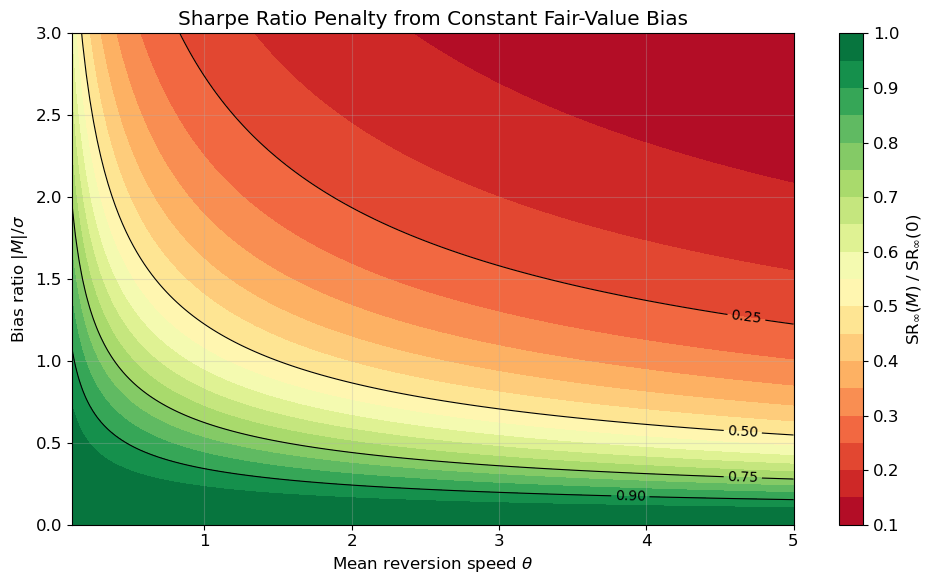

Green = low penalty (bias doesn't hurt much); Red = large penalty.


In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-penalty-heatmap
#| fig-cap: 'SR penalty factor $(1 + \xi^2)^{-1/2}$ where $\xi = |M|/s_\infty = |M|\sqrt{2\theta}/\sigma$, over the $(\theta, |M|/\sigma)$ plane. Green regions indicate low penalty; red regions indicate large penalty.'
# --- Heatmap: SR penalty factor as function of (theta, M/sigma) ---

theta_grid = np.linspace(0.1, 5.0, 200)
m_ratio_grid = np.linspace(0, 3.0, 200)  # M / sigma
Theta, MR = np.meshgrid(theta_grid, m_ratio_grid)

# Penalty = 1 / sqrt(1 + 2*theta*(M/sigma)^2 * sigma^2/sigma^2) = 1 / sqrt(1 + 2*theta*(M/sigma)^2)
# Wait, let me be precise:
# 2*theta*M^2/sigma^2 = 2*theta*(M/sigma)^2
Penalty = 1.0 / np.sqrt(1 + 2 * Theta * MR**2)

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(Theta, MR, Penalty, levels=20, cmap="RdYlGn")
cs = ax.contour(Theta, MR, Penalty, levels=[0.25, 0.5, 0.75, 0.9], colors="k", linewidths=0.8)
ax.clabel(cs, fmt="%.2f", fontsize=10)
plt.colorbar(cf, ax=ax, label=r"$\mathrm{SR}_\infty(M)\;/\;\mathrm{SR}_\infty(0)$")
ax.set(
    xlabel=r"Mean reversion speed $\theta$",
    ylabel=r"Bias ratio $|M|/\sigma$",
    title="Sharpe Ratio Penalty from Constant Fair-Value Bias",

)print("Green = low penalty (bias doesn't hurt much); Red = large penalty.")

plt.tight_layout()plt.show()


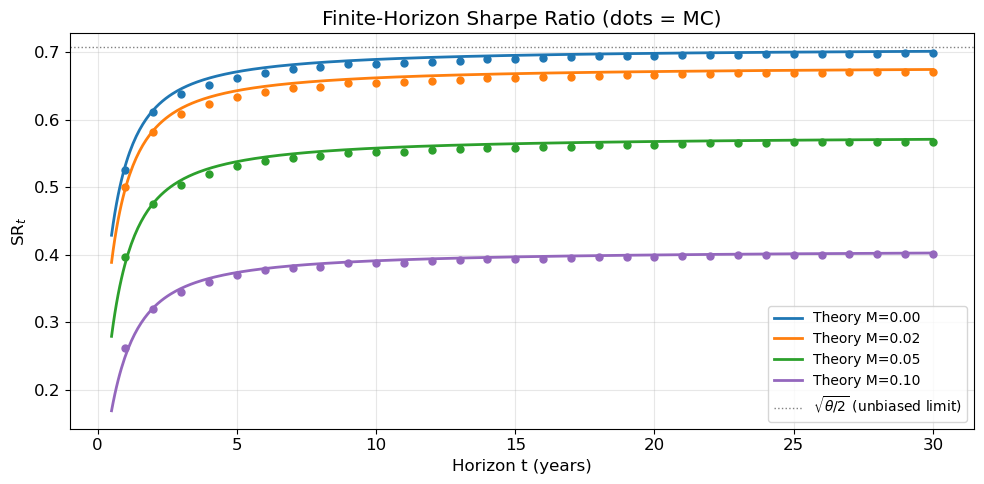

In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-horizon-bias
#| fig-cap: 'Finite-horizon Sharpe ratio $\mathrm{SR}_t$ as a function of trading horizon for different biases $M$. All curves converge to their asymptotic limits (dots = MC).'
# --- Finite-horizon SR_t vs t for different M ---

theta, sigma = 1.0, 0.10
T, dt, n_paths = 30, 1 / 252, 5_000
X = simulate_ou(theta, sigma, T, dt, n_paths)

fig, ax = plt.subplots(figsize=(10, 5))
eval_years = np.arange(1, int(T) + 1)  # evaluate at integer years

for M, c in zip([0.0, 0.02, 0.05, 0.10], plt.cm.tab10(np.linspace(0, 0.4, 4))):
    # Theory
    t_fine = np.linspace(0.5, T, 500)
    alpha = sigma**2 - s2(t_fine, theta, sigma) / t_fine
    sr_th = (alpha / 2) / np.sqrt(sigma**2 * M**2 + sigma**2 / (2 * theta) * alpha)
    ax.plot(t_fine, sr_th, "-", color=c, lw=2, label=f"Theory M={M:.2f}")

    # Simulated
    sr_sim_pts = []
    for yr in eval_years:
        idx = int(yr / dt)
        if idx >= X.shape[1]:
            break
        Y = pnl_paths(X, M, sigma, dt)
        mean_ann = (Y[:, idx] / yr).mean()
        dX = np.diff(X[:, :idx + 1], axis=1)
        X_mid = X[:, :idx]
        dY = -(X_mid - M) * dX
        qv = np.sum(dY**2, axis=1)
        mean_qv_ann = (qv / yr).mean()
        sr_sim_pts.append(mean_ann / np.sqrt(mean_qv_ann))
    ax.plot(eval_years[:len(sr_sim_pts)], sr_sim_pts, "o", color=c, ms=5)

ax.axhline(np.sqrt(theta / 2), color="gray", ls=":", lw=1, label=r"$\sqrt{\theta/2}$ (unbiased limit)")
ax.set(xlabel="Horizon t (years)", ylabel=r"$\mathrm{SR}_t$",

       title="Finite-Horizon Sharpe Ratio (dots = MC)")plt.show()

ax.legend(loc="lower right", fontsize=10)plt.tight_layout()

# Discussion

The central finding of this analysis is the invariance of expected PnL to a constant fair-value bias. A persistent error $M$ in the trader's estimate of fair value does not shift the average outcome (@fig-pnl-bias): since $\int_0^t M\, dX_u = M X_t$ and $\mathbb{E}[X_t] = 0$, the bias-induced PnL has zero mean. This invariance does not extend to risk. The bias creates a systematic offset in the trader's position — even when there is no true mispricing, the trader holds roughly $M$ units of the asset — adding $\sigma^2 M^2$ to the annualised expected quadratic variation and $M^2 s_t^2$ to the terminal variance (@fig-terminal-pnl).

These two effects combine into a penalty on the asymptotic Sharpe ratio. The ratio $\mathrm{SR}_\infty(M)/\mathrm{SR}_\infty(0) = (1 + \xi^2)^{-1/2}$ depends on a single dimensionless quantity $\xi = M/s_\infty$, the bias measured in units of the stationary mispricing scale. A bias equal to $s_\infty$ ($\xi = 1$) reduces the Sharpe ratio by a factor of $1/\sqrt{2} \approx 0.707$, i.e. a 29% reduction; a full 50% reduction requires $\xi = \sqrt{3}$, or $M \approx 1.73\, s_\infty$ (@fig-sr-theta-bias). The penalty is symmetric in $M$ and, for a fixed absolute bias, increases with $\theta$: faster mean reversion shrinks $s_\infty$, so the same constant offset becomes proportionally larger (@fig-sr-penalty-heatmap). The finite-horizon Sharpe ratio converges monotonically to this asymptotic limit (@fig-sr-horizon-bias).

# Extension

The constant-bias model serves as a benchmark against which more realistic estimation structures can be measured. If $M$ is itself a random variable drawn independently of the OU path — as it would be when estimated from a separate data source — the asymptotic Sharpe ratio depends only on $\mathbb{E}[M^2]$. Applying the tower law to the expected quadratic variation formula gives

$$
\mathrm{SR}_\infty = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \mathbb{E}[M^2]/s_\infty^2}},
$$

with $M^2$ replaced by $\mathbb{E}[M^2]$ and the same penalty structure as before. This is not obtained by averaging the pointwise penalty $(1 + \xi^2)^{-1/2}$ over the distribution of $M$; the correct route is the tower-law expectation applied to the quadratic variation formula before taking the ratio. Independence of $M$ and the OU path is the key assumption that makes this work.

A more consequential extension is to allow the bias to be correlated with the price process. Trailing estimators such as moving averages produce precisely this kind of path-dependent, correlated bias, which degrades expected PnL through an additional covariance channel, not merely risk. In the [next post](../mean-reversion-strategy-3/) we develop the correlated-bias framework and show that it subsumes the constant-$M$ results derived here as a special case.
